In [1]:
# Install dependencies
!pip install -q kaggle

# Upload your kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d vbookshelf/v2-plant-seedlings-dataset
!unzip v2-plant-seedlings-dataset.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/nonsegmentedv2/Charlock/308.png  
  inflating: data/nonsegmentedv2/Charlock/309.png  
  inflating: data/nonsegmentedv2/Charlock/31.png  
  inflating: data/nonsegmentedv2/Charlock/310.png  
  inflating: data/nonsegmentedv2/Charlock/311.png  
  inflating: data/nonsegmentedv2/Charlock/312.png  
  inflating: data/nonsegmentedv2/Charlock/313.png  
  inflating: data/nonsegmentedv2/Charlock/314.png  
  inflating: data/nonsegmentedv2/Charlock/315.png  
  inflating: data/nonsegmentedv2/Charlock/316.png  
  inflating: data/nonsegmentedv2/Charlock/317.png  
  inflating: data/nonsegmentedv2/Charlock/318.png  
  inflating: data/nonsegmentedv2/Charlock/319.png  
  inflating: data/nonsegmentedv2/Charlock/32.png  
  inflating: data/nonsegmentedv2/Charlock/320.png  
  inflating: data/nonsegmentedv2/Charlock/321.png  
  inflating: data/nonsegmentedv2/Charlock/322.png  
  inflating: data/nonsegmentedv2/Charlock/323.png  
  inflating: da

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Config
IMAGE_SIZE = 64
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = ImageFolder(root="data", transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Classes:", dataset.classes)

Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'ShepherdтАЩs Purse', 'Small-flowered Cranesbill', 'Sugar beet', 'nonsegmentedv2']


##AE


In [3]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ae = Autoencoder().to(device)

## AE Training

In [4]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(ae.parameters(), lr=0.001)

EPOCHS = 30

for epoch in range(EPOCHS):
    loss_total = 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)

        outputs = ae(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"AE Epoch [{epoch+1}/{EPOCHS}] Loss: {loss_total:.4f}")

AE Epoch [1/30] Loss: 6.0902
AE Epoch [2/30] Loss: 1.7958
AE Epoch [3/30] Loss: 1.2545
AE Epoch [4/30] Loss: 1.0486
AE Epoch [5/30] Loss: 0.8509
AE Epoch [6/30] Loss: 0.7276
AE Epoch [7/30] Loss: 0.6495
AE Epoch [8/30] Loss: 0.5903
AE Epoch [9/30] Loss: 0.5452
AE Epoch [10/30] Loss: 0.5112
AE Epoch [11/30] Loss: 0.4917
AE Epoch [12/30] Loss: 0.4591
AE Epoch [13/30] Loss: 0.4749
AE Epoch [14/30] Loss: 0.4466
AE Epoch [15/30] Loss: 0.4228
AE Epoch [16/30] Loss: 0.3971
AE Epoch [17/30] Loss: 0.3951
AE Epoch [18/30] Loss: 0.3652
AE Epoch [19/30] Loss: 0.3681
AE Epoch [20/30] Loss: 0.3404
AE Epoch [21/30] Loss: 0.3246
AE Epoch [22/30] Loss: 0.3145
AE Epoch [23/30] Loss: 0.3022
AE Epoch [24/30] Loss: 0.2930
AE Epoch [25/30] Loss: 0.2769
AE Epoch [26/30] Loss: 0.2740
AE Epoch [27/30] Loss: 0.2770
AE Epoch [28/30] Loss: 0.2601
AE Epoch [29/30] Loss: 0.2472
AE Epoch [30/30] Loss: 0.2510


## AE Results

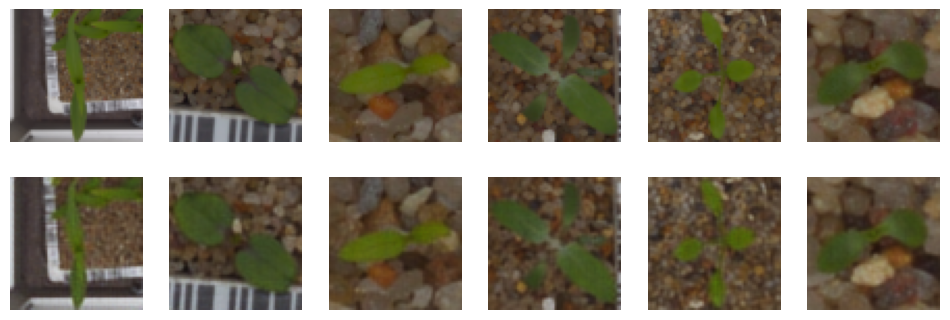

In [5]:
import matplotlib.pyplot as plt

def show_ae_results(model):
    model.eval()
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)

    with torch.no_grad():
        outputs = model(imgs)

    imgs = imgs.cpu()
    outputs = outputs.cpu()

    fig, axes = plt.subplots(2, 6, figsize=(12,4))

    for i in range(6):
        axes[0,i].imshow(imgs[i].permute(1,2,0)*0.5+0.5)
        axes[0,i].axis('off')

        axes[1,i].imshow(outputs[i].permute(1,2,0)*0.5+0.5)
        axes[1,i].axis('off')

    plt.show()

show_ae_results(ae)

## GAN (DCGAN)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 64
BATCH_SIZE = 32
LATENT_DIM = 100
EPOCHS = 60   # good balance for results + time

In [10]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # FIXED
])

dataset = ImageFolder(root="data", transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Classes:", dataset.classes)

Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'ShepherdтАЩs Purse', 'Small-flowered Cranesbill', 'Sugar beet', 'nonsegmentedv2']


## Generator

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

## Discriminator

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(512*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Initialize Models

In [13]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [14]:
z = torch.randn(1, LATENT_DIM, 1, 1).to(device)
fake = G(z)
print("Generator Output Shape:", fake.shape)  # MUST be [1,3,64,64]

Generator Output Shape: torch.Size([1, 3, 64, 64])


## GAN Training

Epoch [1/60] | D Loss: 1.1419 | G Loss: 7.2874
Epoch [2/60] | D Loss: 4.0596 | G Loss: 5.0360
Epoch [3/60] | D Loss: 2.1671 | G Loss: 0.0134
Epoch [4/60] | D Loss: 0.5710 | G Loss: 6.1248
Epoch [5/60] | D Loss: 1.4345 | G Loss: 8.0359
Epoch [6/60] | D Loss: 0.0863 | G Loss: 0.8247
Epoch [7/60] | D Loss: 1.6955 | G Loss: 2.2222
Epoch [8/60] | D Loss: 4.9850 | G Loss: 0.7071
Epoch [9/60] | D Loss: 1.5820 | G Loss: 0.3956
Epoch [10/60] | D Loss: 2.3500 | G Loss: 10.1052


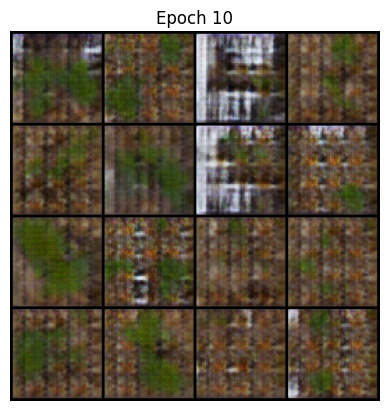

Epoch [11/60] | D Loss: 0.0265 | G Loss: 8.1507
Epoch [12/60] | D Loss: 0.0225 | G Loss: 9.2339
Epoch [13/60] | D Loss: 0.3671 | G Loss: 2.1149
Epoch [14/60] | D Loss: 0.2893 | G Loss: 6.1418
Epoch [15/60] | D Loss: 0.0575 | G Loss: 3.9035
Epoch [16/60] | D Loss: 0.9462 | G Loss: 2.3888
Epoch [17/60] | D Loss: 0.3592 | G Loss: 3.1814
Epoch [18/60] | D Loss: 0.1140 | G Loss: 5.9444
Epoch [19/60] | D Loss: 0.3737 | G Loss: 2.8645
Epoch [20/60] | D Loss: 0.6501 | G Loss: 7.4320


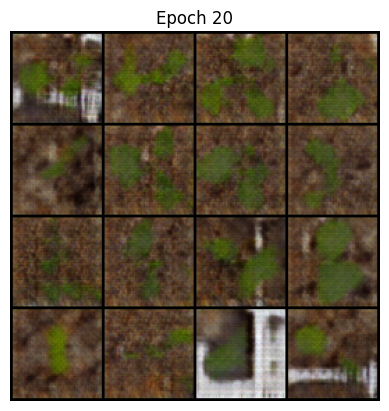

Epoch [21/60] | D Loss: 0.1086 | G Loss: 7.4783
Epoch [22/60] | D Loss: 0.0052 | G Loss: 4.4595
Epoch [23/60] | D Loss: 0.5694 | G Loss: 7.3728
Epoch [24/60] | D Loss: 0.0468 | G Loss: 3.0998
Epoch [25/60] | D Loss: 0.2000 | G Loss: 3.4686
Epoch [26/60] | D Loss: 0.1081 | G Loss: 1.8930
Epoch [27/60] | D Loss: 2.2528 | G Loss: 0.6404
Epoch [28/60] | D Loss: 0.7858 | G Loss: 2.4130
Epoch [29/60] | D Loss: 1.7224 | G Loss: 0.8994
Epoch [30/60] | D Loss: 2.4243 | G Loss: 0.7166


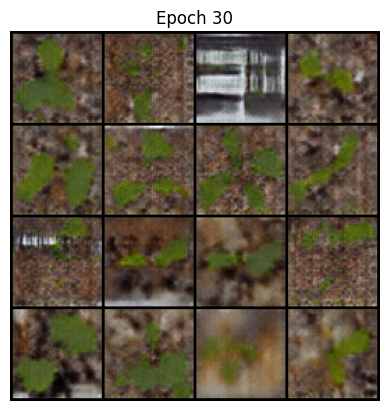

Epoch [31/60] | D Loss: 6.1459 | G Loss: 1.3485
Epoch [32/60] | D Loss: 0.0044 | G Loss: 8.1377
Epoch [33/60] | D Loss: 2.7269 | G Loss: 0.6795
Epoch [34/60] | D Loss: 1.0527 | G Loss: 2.6998
Epoch [35/60] | D Loss: 5.0867 | G Loss: 0.2411
Epoch [36/60] | D Loss: 3.0864 | G Loss: 1.1867
Epoch [37/60] | D Loss: 0.0068 | G Loss: 4.4008
Epoch [38/60] | D Loss: 0.3734 | G Loss: 2.8987
Epoch [39/60] | D Loss: 1.5720 | G Loss: 2.9869
Epoch [40/60] | D Loss: 3.6281 | G Loss: 0.6375


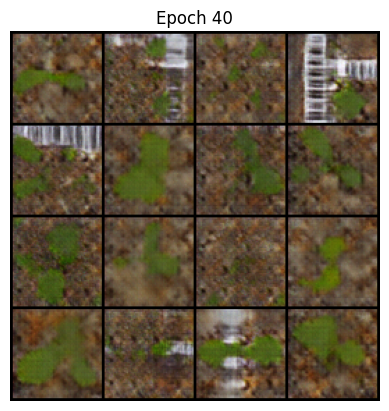

Epoch [41/60] | D Loss: 0.1180 | G Loss: 1.8301
Epoch [42/60] | D Loss: 2.6728 | G Loss: 1.2102
Epoch [43/60] | D Loss: 3.1605 | G Loss: 2.0358
Epoch [44/60] | D Loss: 0.0017 | G Loss: 7.1487
Epoch [45/60] | D Loss: 0.0189 | G Loss: 7.6744
Epoch [46/60] | D Loss: 2.6381 | G Loss: 2.5178
Epoch [47/60] | D Loss: 4.3764 | G Loss: 6.8957
Epoch [48/60] | D Loss: 0.0137 | G Loss: 8.6213
Epoch [49/60] | D Loss: 0.0262 | G Loss: 4.7957
Epoch [50/60] | D Loss: 0.0076 | G Loss: 6.8204


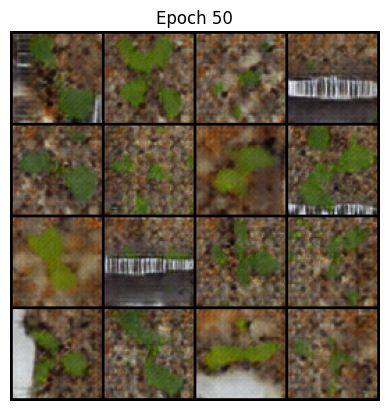

Epoch [51/60] | D Loss: 0.4449 | G Loss: 1.4704
Epoch [52/60] | D Loss: 1.4173 | G Loss: 0.1568
Epoch [53/60] | D Loss: 0.0057 | G Loss: 3.7660
Epoch [54/60] | D Loss: 0.1101 | G Loss: 0.8504
Epoch [55/60] | D Loss: 4.0556 | G Loss: 3.1006
Epoch [56/60] | D Loss: 0.1046 | G Loss: 7.3789
Epoch [57/60] | D Loss: 0.0140 | G Loss: 2.0678
Epoch [58/60] | D Loss: 1.4488 | G Loss: 0.4828
Epoch [59/60] | D Loss: 0.0294 | G Loss: 10.2324
Epoch [60/60] | D Loss: 0.0162 | G Loss: 5.5180


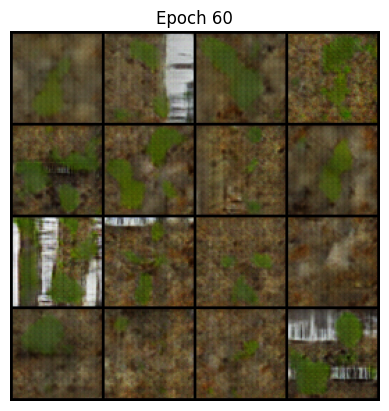

In [15]:
G_losses = []
D_losses = []

for epoch in range(EPOCHS):
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        batch_size = imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_imgs = G(z)

        loss_real = criterion(D(imgs), real_labels)
        loss_fake = criterion(D(fake_imgs.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_imgs = G(z)

        loss_G = criterion(D(fake_imgs), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {loss_D:.4f} | G Loss: {loss_G:.4f}")

    # Show results every 10 epochs
    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, LATENT_DIM, 1, 1).to(device)
            samples = G(z).cpu()

            grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True)
            plt.imshow(grid.permute(1,2,0))
            plt.title(f"Epoch {epoch+1}")
            plt.axis("off")
            plt.show()

## GAN Results

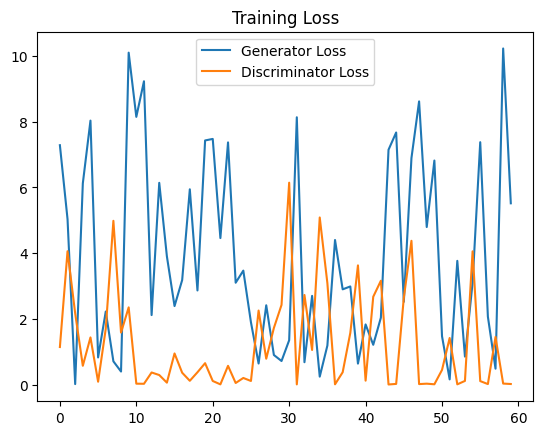

In [16]:
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

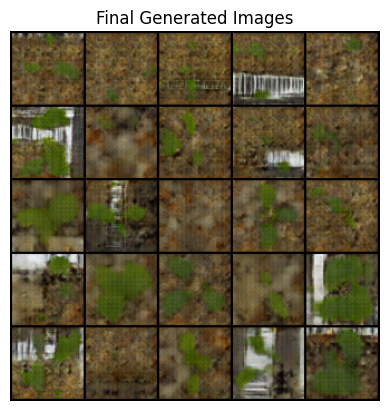

In [17]:
with torch.no_grad():
    z = torch.randn(25, LATENT_DIM, 1, 1).to(device)
    samples = G(z).cpu()

    grid = torchvision.utils.make_grid(samples, nrow=5, normalize=True)
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Final Generated Images")
    plt.show()